# 05 · How much of the result survives costs, assumptions and the Covid crash?

Part 5 of 5. The previous notebook gave the headline numbers. This one asks how much they can be trusted.

1. **Sensitivity**: which assumption matters most?
2. **Stress episodes**: what happened in each market shock since 2020?
3. **Tail statistics**: VaR, CVaR, worst months.
4. **Robustness**: does the result survive without the single largest event, the Covid crash?
5. **Selection bias**: how much of the Sharpe ratio is luck given the number of variants tried?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from vrp.data import load_market_data
from vrp.volatility import forward_realized_variance, log_returns

END = "2026-09-25"                   # last complete session used for the published results
EVAL_START = pd.Timestamp("2020-01-01")

data = load_market_data("yahoo", "1990-01-01", END)
spx, vix = data["spx"], data["vix"]
returns = log_returns(spx)
realized_var = forward_realized_variance(returns)   # RV(t, t+21), annualised
realized_vol = np.sqrt(realized_var)
implied_var = (vix / 100) ** 2
print(f"{len(data):,} daily observations, {spx.index[0].date()} to {spx.index[-1].date()}")

9,251 daily observations, 1990-01-02 to 2026-09-25


In [2]:
from vrp.backtest import StraddleConfig
from vrp.metrics import expected_max_sharpe, performance_summary, sharpe_per_period, stress_table
from vrp.pipeline import run_strategies, sensitivity_table, summarize_strategies
from vrp.plots import PALETTE, style
from vrp.report import as_percent
from vrp.volatility import walk_forward_har

har_x, _ = walk_forward_har(returns, implied_variance=implied_var)
first = max(EVAL_START, har_x.first_valid_index())
sample, vix_sample = spx.loc[first:], vix.loc[first:]

base = StraddleConfig()
runs = run_strategies(sample, vix_sample, har_x, base)
returns_by_strategy, summary = summarize_strategies(runs)

## 1 · Which assumption moves the result most?

In [3]:
sensitivity = sensitivity_table(sample, vix_sample, base)
as_percent(sensitivity, ["ann_return", "max_drawdown", "worst_month"]).round(2)

,ann_return (%),sharpe,max_drawdown (%),worst_month (%)
scenario,,,,
Base case (ATM vol = VIX - 2 pts),3.9,0.70,-13.6,-8.3
No transaction costs,5.0,0.90,-13.1,-8.2
Option half-spread 0.5 vol pt,3.2,0.58,-13.9,-8.4
Option half-spread 1.0 vol pt,1.9,0.33,-14.4,-8.5
ATM vol = VIX (no skew adjustment),9.2,1.65,-12.8,-8.3
ATM vol = VIX - 3 pts,1.3,0.23,-14.5,-8.3
ATM vol = VIX - 4 pts,-1.3,-0.23,-17.5,-8.3
Half notional,2.0,0.70,-6.8,-4.1


The assumption that changes the result most is the level of the at-the-money implied volatility, which is not observed and is proxied by the VIX minus a shift. Costs matter too, but they move the return by a point or two, not by its sign.

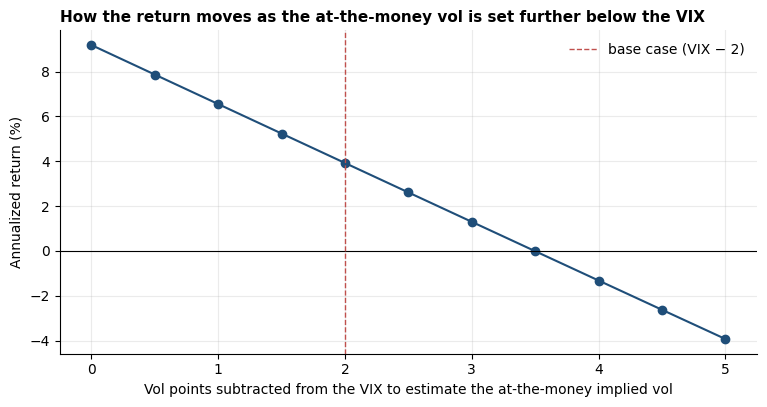

In [4]:
from vrp.backtest import backtest_short_straddle

shifts = np.arange(0.0, -5.01, -0.5)
rows = []
for shift in shifts:
    daily, _ = backtest_short_straddle(sample, vix_sample, config=base.with_(iv_shift=float(shift)))
    stats = performance_summary(daily["return"])
    rows.append({"shift": shift, "ann_return": stats["ann_return"], "sharpe": stats["sharpe"]})
curve = pd.DataFrame(rows).set_index("shift")

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(-curve.index, 100 * curve["ann_return"], marker="o", color=PALETTE[0])
ax.axhline(0, color="black", lw=0.8)
ax.axvline(2, color=PALETTE[1], ls="--", lw=1, label="base case (VIX − 2)")
ax.set_xlabel("Vol points subtracted from the VIX to estimate the at-the-money implied vol")
ax.set_ylabel("Annualized return (%)")
ax.legend(frameon=False)
style(ax, "How the return moves as the at-the-money vol is set further below the VIX")
plt.close(fig)
fig

Every extra point subtracted from the VIX takes about 2.6 percentage points a year off the return, and the strategy turns negative between three and four points. Whether the true at-the-money implied volatility sat 2 or 4 points below the VIX over these years is exactly what a proxy cannot tell. Real option quotes would remove this uncertainty, and using them is the first improvement worth making.

## 2 · What happened in each market shock

In [5]:
stress = stress_table(returns_by_strategy, sample, vix_sample)
stress.index.name = "episode"
stress = stress.rename(columns={"spx_return": "S&P 500", "vix_peak": "VIX peak"})
percent_columns = [c for c in stress.columns if c != "VIX peak"]
as_percent(stress, percent_columns).round(1)

,S&P 500 (%),VIX peak,"Short straddle, delta-hedged (%)","Short straddle, unhedged (%)",VRP filter > 0 vol pts (%),VRP filter > 2 vol pts (%),VRP filter > 4 vol pts (%)
episode,,,,,,,
Covid crash 2020,-14.0,82.7,-11.1,-16.2,-4.0,-4.0,0.0
Tech selloff Sep 2020,-8.7,40.3,-0.1,3.7,-0.1,-0.1,-0.1
Retail squeeze Jan 2021,0.8,37.2,0.5,2.5,0.5,-0.7,-0.7
Omicron Nov-Dec 2021,-2.5,31.1,0.5,3.9,0.5,0.5,1.8
Rate shock 2022,-19.3,36.5,-3.2,-2.7,-3.2,-3.2,2.5
Regional banks Mar 2023,2.9,26.5,0.6,2.4,0.6,0.6,0.0
Yield spike Oct 2023,-5.8,21.7,-0.2,-1.2,-0.2,-0.2,0.0
Yen carry unwind Aug 2024,0.6,38.6,1.4,-3.4,1.4,1.4,0.0
Tariff shock Apr 2025,-1.1,52.3,-3.0,-9.0,-3.0,-3.0,1.1


Each row is a window around a shock, and the columns are the cumulative return of each strategy over that window, in percent of capital. The Covid crash is the only episode that really hurts: −11.1% for the hedged strategy, against −3.2% for the 2022 rate shock and −3.0% for the April 2025 tariff shock, which are the next worst. The filtered strategies come out of the Covid crash with about a third of the loss (−4.0%), or none at all for the 4-point filter, because they had no position open when it started. Episodes with a very high VIX peak that reversed quickly, such as August 2024, cost nothing: the hedged strategy gained 1.4% there.

## 3 · How bad the worst days and months are

In [6]:
tail_columns = ["var_95", "cvar_95", "var_99", "cvar_99", "worst_day", "worst_month", "skew", "excess_kurtosis"]
tails = summary[tail_columns].copy()
as_percent(tails, ["var_95", "cvar_95", "var_99", "cvar_99", "worst_day", "worst_month"], digits=2).round(2)

,var_95 (%),cvar_95 (%),var_99 (%),cvar_99 (%),worst_day (%),worst_month (%),skew,excess_kurtosis
strategy,,,,,,,,
"Short straddle, delta-hedged",0.45,1.05,1.40,2.22,-4.27,-8.30,-3.79,31.24
"Short straddle, unhedged",1.24,2.11,2.62,4.08,-9.65,-9.00,-1.18,26.19
VRP filter > 0 vol pts,0.43,0.95,1.32,1.97,-4.27,-2.98,-3.86,35.68
VRP filter > 2 vol pts,0.42,0.93,1.25,1.96,-4.27,-2.98,-4.06,39.02
VRP filter > 4 vol pts,0.06,0.39,0.43,1.22,-4.27,-1.22,-7.22,147.54


VaR at 99% is the loss exceeded on 1% of days; CVaR is the average loss on those days. For the hedged strategy the CVaR at 99% is about 1.6 times the VaR (2.2% against 1.4%), where a normal distribution would give 1.15 times. The excess kurtosis of 31 confirms that the tails are much fatter than normal.

In [7]:
monthly = returns_by_strategy["Short straddle, delta-hedged"].resample("ME").sum()
worst = (100 * monthly.nsmallest(5)).round(2).rename("monthly P&L (% of capital)")
worst.index = worst.index.strftime("%Y-%m")
worst.to_frame()

,monthly P&L (% of capital)
date,
2020-03,-8.30
2025-04,-2.98
2020-02,-2.91
2024-07,-1.34
2020-06,-1.22


## 4 · The result with the Covid crash, and after it

In [8]:
after = "2020-06-01"
rows = {}
for name, r in returns_by_strategy.items():
    full, later = performance_summary(r), performance_summary(r.loc[after:])
    rows[name] = {
        "Sharpe over the full window": full["sharpe"],
        f"Sharpe after {after}": later["sharpe"],
        "max drawdown over the full window (%)": 100 * full["max_drawdown"],
        f"max drawdown after {after} (%)": 100 * later["max_drawdown"],
    }
pd.DataFrame(rows).T.round(2)

,Sharpe over the full window,Sharpe after 2020-06-01,max drawdown over the full window (%),max drawdown after 2020-06-01 (%)
"Short straddle, delta-hedged",0.70,1.08,-13.57,-5.90
"Short straddle, unhedged",0.00,0.18,-24.23,-24.23
VRP filter > 0 vol pts,0.97,1.08,-6.53,-5.90
VRP filter > 2 vol pts,0.89,1.01,-6.53,-5.53
VRP filter > 4 vol pts,0.98,0.92,-4.59,-4.59


Once the first months of 2020 are left out, the advantage of the filter disappears. From June 2020 the unfiltered strategy has a Sharpe ratio of 1.08, identical to the loosest filter, with the same maximum drawdown (−5.9%), and the most selective filter is slightly worse (0.92). The forecast filter did not find a steady edge: its value over the full window comes from having stayed out of one crash. That is real, but it rests on a single event and should not be presented as a proven improvement. Starting a window right after the crash flatters every strategy, so this table shows how much the crash matters, not what to expect next.

## 5 · How much of the Sharpe ratio is luck?

In [9]:
trial_sharpes = [sharpe_per_period(r) for r in returns_by_strategy.values()]
threshold = expected_max_sharpe(trial_sharpes) * np.sqrt(252)
best_name = summary["sharpe"].idxmax()

display(Markdown(
    f"Five variants were tested. Even if none had any edge, the best of five would be expected to show an annualized Sharpe ratio of about "
    f"**{threshold:.2f}** by chance alone, given how far apart their Sharpe ratios are. The best variant, *{best_name}*, has "
    f"**{summary.loc[best_name, 'sharpe']:.2f}**."
))
summary[["sharpe", "psr_vs_0", "deflated_sharpe"]].round(2)

Five variants were tested. Even if none had any edge, the best of five would be expected to show an annualized Sharpe ratio of about **0.49** by chance alone, given how far apart their Sharpe ratios are. The best variant, *VRP filter > 4 vol pts*, has **0.98**.

,sharpe,psr_vs_0,deflated_sharpe
strategy,,,
"Short straddle, delta-hedged",0.70,0.95,0.69
"Short straddle, unhedged",0.00,0.50,0.10
VRP filter > 0 vol pts,0.97,0.99,0.86
VRP filter > 2 vol pts,0.89,0.98,0.82
VRP filter > 4 vol pts,0.98,0.98,0.84


The **probabilistic Sharpe ratio (PSR)** is the probability that the true Sharpe is above zero given the length of the sample and the skew and kurtosis of the returns. The **deflated Sharpe ratio (DSR)** applies the same test against the threshold above, that is, against the best result one would expect from luck among the variants tried. Both are high for the filtered variants and low for the unhedged one. A DSR of 0.8 to 0.9 is encouraging, but it comes from a window with one large crisis and a loosest filter that skips only two of the 80 months.

## Conclusions

- The volatility risk premium is real over 2020-2026: the VIX was above subsequent realized volatility on about 85% of days, by 3.8 points on average.
- It cannot be forecast better than the VIX itself with HAR or GARCH models. HAR-X reduces the bias and the RMSE slightly but not the losses that matter.
- A delta-hedged short straddle turned that premium into a modest positive return after costs, with a strongly negative skew and one severe drawdown.
- The result depends on an assumption that cannot be checked without option quotes: how far the at-the-money implied volatility sits below the VIX.
- A forecast filter improves the risk-adjusted numbers, but almost entirely through one avoided crash.

**Limits.** Black-Scholes with one volatility for all strikes and no rates or dividends; execution at the close with fixed costs; no margin constraints; six and a half years and two large volatility spikes.